# UK Food Price Tracker: walkthrough

This notebook walks through the whole project one step at a time. Each step says **what** I'm doing and **why**, runs the code, and then says what the result means.

**The question:** food prices rose sharply after 2021. Which foods actually caused the rise, and was it the same everywhere?

**The data:** three free files from the Office for National Statistics (ONS), saved in `../data/`:
- `mm23.csv`: monthly price indices and spending weights for every food category
- `upload-pricequotes202101.csv` and `upload-pricequotes202501.csv`: individual shop prices collected by ONS in January 2021 and January 2025

> The cleaned-up, final version of this logic lives in `src/food_price_pipeline.py`. This notebook is the "show your working" version.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = "../data/"
pd.set_option("display.width", 140)

## Step 1: Category price trends

ONS tracks prices with an **index**: each category is set to **100 in 2015**, and the number moves as prices change. If bread is 120 in one month and 150 later, prices rose by 25% between those months (150 ÷ 120 − 1).

The `mm23.csv` file is wide: one column per series, with the series name in the header. The first rows are metadata, and the data rows are labelled like `2021 JAN`. So the first job is to pull out the monthly rows and the food columns.

In [2]:
mm = pd.read_csv(DATA + "mm23.csv", low_memory=False).set_index("Title")

monthly_rows = [i for i in mm.index if re.fullmatch(r"\d{4} [A-Z]{3}", str(i))]   # e.g. '2021 JAN'
yearly_rows  = [i for i in mm.index if re.fullmatch(r"\d{4}", str(i))]            # e.g. '2021' (weights are yearly)

CATEGORIES = {
    "01.1.1": "Bread & cereals", "01.1.2": "Meat", "01.1.3": "Fish",
    "01.1.4": "Milk, cheese & eggs", "01.1.5": "Oils & fats", "01.1.6": "Fruit",
    "01.1.7": "Vegetables", "01.1.8": "Sugar, jam & confectionery",
    "01.1.9": "Other food products", "01.2.1": "Coffee, tea & cocoa",
    "01.2.2": "Water, soft drinks & juices",
}

def find_col(prefix, code):
    """Find the one column whose name starts with e.g. 'CPI INDEX 01.1.1 :'."""
    hits = [c for c in mm.columns if re.match(rf"^{prefix} {re.escape(code)}\s*:", c)]
    assert len(hits) == 1, (prefix, code, hits)   # stop if the name is ambiguous
    return hits[0]

print(find_col("CPI INDEX", "01.1.1"))
print(find_col("CPI WEIGHTS", "01.1.1"))

CPI INDEX 01.1.1 : BREAD & CEREALS 2015=100
CPI WEIGHTS 01.1.1 : BREAD & CEREALS


In [3]:
M = mm.loc[monthly_rows]
M.index = pd.to_datetime(M.index, format="%Y %b")

index = pd.DataFrame({name: pd.to_numeric(M[find_col("CPI INDEX", code)], errors="coerce")
                      for code, name in CATEGORIES.items()})
index["Food & non-alcoholic drinks"] = pd.to_numeric(M[find_col("CPI INDEX", "01")], errors="coerce")
index["All CPI items"] = pd.to_numeric(M["CPI INDEX 00: ALL ITEMS 2015=100"], errors="coerce")
index = index.loc["2019-01-01":]

print("Latest month in the data:", index.index.max().strftime("%B %Y"))
index[["Bread & cereals", "Oils & fats", "Food & non-alcoholic drinks", "All CPI items"]].tail(3)

Latest month in the data: August 2026


,Bread & cereals,Oils & fats,Food & non-alcoholic drinks,All CPI items
Title,,,,
2026-06-01,142.9,186.3,144.0,142.5
2026-07-01,143.4,185.7,144.0,142.9
2026-08-01,143.5,185.5,144.6,143.6


In [4]:
start, latest = pd.Timestamp("2021-01-01"), index.index.max()
since_2021 = ((index.loc[latest] / index.loc[start] - 1) * 100).round(1).sort_values(ascending=False)
since_2021.to_frame("% change since Jan 2021")

,% change since Jan 2021
Oils & fats,69.7
Other food products,57.4
"Milk, cheese & eggs",47.8
"Coffee, tea & cocoa",45.6
"Sugar, jam & confectionery",45.1
Vegetables,40.4
Food & non-alcoholic drinks,39.8
"Water, soft drinks & juices",39.5
Bread & cereals,37.3
Meat,36.8


**What this shows:** food and soft drinks are up about 40% since January 2021, well ahead of prices overall (about 32%). Oils and fats rose the most, by around 70%.

But "rose the most" isn't the same as "caused the most". That's Step 2.

Food inflation peaked at 19.2% in March 2023; latest: 1.3%


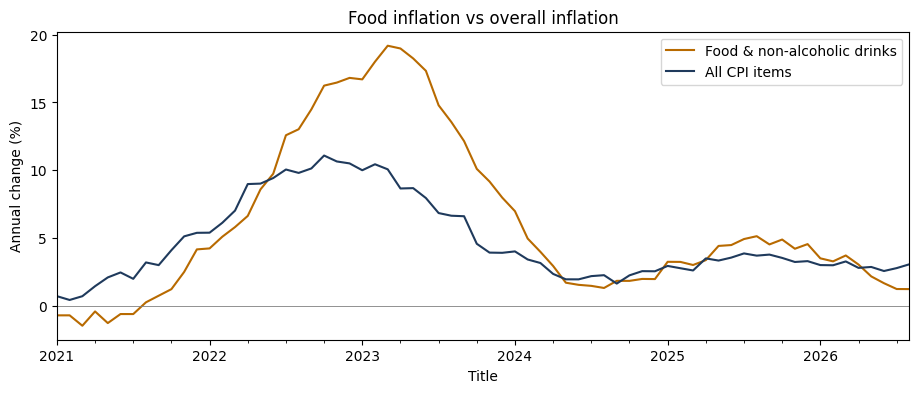

In [5]:
annual = (index / index.shift(12) - 1) * 100        # annual rate = this month vs the same month last year
food_rate = annual["Food & non-alcoholic drinks"].loc[start:]
peak = food_rate.idxmax()
print(f"Food inflation peaked at {food_rate.max():.1f}% in {peak:%B %Y}; latest: {food_rate.iloc[-1]:.1f}%")

ax = annual.loc[start:, ["Food & non-alcoholic drinks", "All CPI items"]].plot(figsize=(11, 4), color=["#B86A00", "#1F3A5C"])
ax.axhline(0, color="grey", lw=0.6); ax.set_ylabel("Annual change (%)"); ax.set_title("Food inflation vs overall inflation")
plt.show()

## Step 2: Which categories drove the rise?

People don't spend the same amount on every category. ONS publishes **weights** showing each category's share of spending.

A simple example: if oils and fats rise 30% but are only 2% of food spending, they add about 0.6 points (30 × 0.02) to food inflation. Dairy rising 30% at 15% of spending adds 4.5 points. **Same rise, very different impact on the shopping bill.**

So: contribution = category weight ÷ total food weight × category annual rate, using each year's weights.

In [6]:
weights = pd.DataFrame({name: pd.to_numeric(mm.loc[yearly_rows, find_col("CPI WEIGHTS", code)], errors="coerce")
                        for code, name in CATEGORIES.items()})
weights.index = weights.index.astype(int)
food_weight = pd.to_numeric(mm.loc[yearly_rows, find_col("CPI WEIGHTS", "01")], errors="coerce")
food_weight.index = food_weight.index.astype(int)

contrib = pd.DataFrame({
    month: weights.loc[month.year] / food_weight.loc[month.year] * annual.loc[month, list(CATEGORIES.values())]
    for month in annual.loc[start:].index
}).T

at_peak = contrib.loc[peak].sort_values(ascending=False).round(2)
at_peak.to_frame(f"points of the {food_rate.max():.1f}% peak")

,points of the 19.2% peak
"Milk, cheese & eggs",3.49
Bread & cereals,3.42
Meat,2.94
Vegetables,2.43
"Sugar, jam & confectionery",1.90
Other food products,1.25
"Water, soft drinks & juices",1.00
Fruit,0.89
Oils & fats,0.86
Fish,0.70


**Check before trusting it:** if the method is right, the contributions should add up to the official food inflation rate. If they don't, something is wrong.

In [7]:
gap = (contrib.sum(axis=1) - food_rate).abs()
print(f"Average gap between my contributions and the official rate: {gap.mean():.2f} percentage points")

Average gap between my contributions and the official rate: 0.07 percentage points


**What this shows:** the gap is tiny, so the breakdown can be trusted. At the peak, **milk, cheese & eggs** and **bread & cereals** drove the most. **Oils and fats**, the biggest riser, added less than one point, because people spend relatively little on them.

*(The small gap exists because ONS chain-links its indices; using fixed yearly weights is a close approximation, not an exact copy.)*

## Step 3: Real shop prices, compared like for like

ONS also publishes the individual prices its collectors record in shops: one row per product, per shop, per month.

First, keep only what's usable:
- **food items** (ONS item codes starting 21xxxx)
- **valid quotes** (validity code 3 or 4)
- **a real price** (a price of 0 means nothing was collected)

In [8]:
def load_quotes(file):
    d = pd.read_csv(DATA + file)
    d.columns = d.columns.str.strip()
    return d[d.ITEM_ID.between(210000, 219999) & d.VALIDITY.isin([3, 4]) & (d.PRICE > 0)]

q21 = load_quotes("upload-pricequotes202101.csv")
q25 = load_quotes("upload-pricequotes202501.csv")
print(f"Usable food prices: {len(q21):,} in Jan 2021 and {len(q25):,} in Jan 2025")
q25[["ITEM_DESC", "PRICE", "REGION", "SHOP_CODE", "SHOP_TYPE"]].head()

Usable food prices: 33,245 in Jan 2021 and 42,613 in Jan 2025


,ITEM_DESC,PRICE,REGION,SHOP_CODE,SHOP_TYPE
0,LGE LOAF-WHTE-UNSLED-750-800G,1.45,2,801,1
1,LGE LOAF-WHTE-UNSLED-750-800G,2.00,2,802,1
2,LGE LOAF-WHTE-UNSLED-750-800G,1.40,2,803,1
3,LGE LOAF-WHTE-UNSLED-750-800G,1.50,2,807,1
4,LGE LOAF-WHTE-UNSLED-750-800G,1.50,2,808,1


### Why a simple comparison misleads

The obvious approach is to compare the typical (median) price of each product in 2021 and 2025. The problem: **different shops are visited each year**, and product definitions are loose (a "whole sponge cake" can be many different cakes). So the comparison mixes real price change with *what happened to be sampled*.

In [9]:
naive = (q25.groupby("ITEM_ID").PRICE.median() / q21.groupby("ITEM_ID").PRICE.median() - 1) * 100
names = q25.groupby("ITEM_ID").ITEM_DESC.first()
for item in ["WHOLE SPONGE CAKE NOT FROZEN", "HONEY JAR/BOTTLE 340G-454G"]:
    item_id = names[names == item].index[0]
    print(f"{item.title():35s} naive change: {naive[item_id]:+.0f}%")

Whole Sponge Cake Not Frozen        naive change: +218%
Honey Jar/Bottle 340G-454G          naive change: -23%


A sponge cake tripling in price and honey getting a quarter cheaper don't sound right.

### The fix: same product, same shop

Instead, match the **same product in the same shop and region** in both years, and look at how *that shop's* price changed. Then average those changes for each product.

**Why a geometric mean?** Price changes multiply rather than add. If a price doubles (×2) and then halves (×0.5), it ends up exactly where it started. An ordinary average of 2 and 0.5 is 1.25, which wrongly says it went *up* 25%. A geometric mean gives 1.0, which is correct.

In [10]:
print("Ordinary average of ×2 and ×0.5:", np.mean([2, 0.5]))
print("Geometric mean of ×2 and ×0.5: ", np.exp(np.mean(np.log([2, 0.5]))))

Ordinary average of ×2 and ×0.5: 1.25
Geometric mean of ×2 and ×0.5:  1.0


In [11]:
key = ["ITEM_ID", "REGION", "SHOP_CODE"]
a = q21.groupby(key).agg(p21=("PRICE", "mean"), shop_type=("SHOP_TYPE", "first")).reset_index()
b = q25.groupby(key).agg(p25=("PRICE", "mean")).reset_index()
pairs = a.merge(b, on=key)
pairs["relative"] = pairs.p25 / pairs.p21

# A price more than 5x higher, or below a fifth, is almost always a different product or pack size, not inflation.
suspicious = pairs[(pairs.relative <= 0.2) | (pairs.relative >= 5)]
pairs = pairs[(pairs.relative > 0.2) & (pairs.relative < 5)]
print(f"Matched pairs: {len(pairs):,}  (excluded {len(suspicious)} implausible matches)")

Matched pairs: 21,766  (excluded 67 implausible matches)


In [12]:
geo = lambda r: (np.exp(np.log(r).mean()) - 1) * 100
items = pairs.groupby("ITEM_ID").agg(pairs=("relative", "size"), change=("relative", geo))
items = items[items.pairs >= 20]           # only products seen in at least 20 shops
items["item"] = names.reindex(items.index).str.title()
items["naive"] = naive.reindex(items.index).round(1)
items = items.sort_values("change", ascending=False)

print("Sponge cake and honey, matched:")
print(items[items.item.str.contains("Sponge|Honey")][["item", "naive", "change"]].round(1).to_string(index=False))
items[["item", "pairs", "change"]].round(1).head(10)

Sponge cake and honey, matched:
                        item  naive  change
Whole Sponge Cake Not Frozen  218.2    91.0
  Honey Jar/Bottle 340G-454G  -23.4     1.1


,item,pairs,change
ITEM_ID,,,
211408,Olive Oil - 500Ml - 1 Litre,165,112.1
210320,Whole Sponge Cake Not Frozen,78,91.0
212938,Chocolate Covered Ice Cream,182,86.5
212006,Fruit Juice Not Orange 1L,81,72.8
212510,Fresh Veg-Cucumber-Whole,212,71.7
212917,Tomato Ketchup Bottle 340-570G,169,70.3
212020,Fruit Drink Bottle 4-8 Pack,170,67.7
212511,Fresh Veg-Lettuce-Iceberg-Each,191,65.7
212910,Canned Soup-390-425G,82,65.3


**Check before trusting it:** across all products, the typical like-for-like rise should land close to ONS's official food inflation for the same months. If it doesn't, the matching isn't measuring real price change.

In [13]:
official = (index.loc["2025-01-01", "Food & non-alcoholic drinks"] / index.loc["2021-01-01", "Food & non-alcoholic drinks"] - 1) * 100
print(f"My typical like-for-like rise: {items.change.median():.1f}%")
print(f"Official ONS food change:      {official:.1f}%")

My typical like-for-like rise: 33.4%
Official ONS food change:      34.4%


**What this shows:** the two are very close, so the matched comparison measures genuine price change. Olive oil more than doubled. Honey barely moved once compared fairly.

## Step 4: Regions and shop types

**Regions:** to compare fairly, use the same basket of products in every region, keeping only products priced in all 12. (Region 1 is ONS's head-office catalogue collection, not a real region, so it's left out.)

In [14]:
REGIONS = {2: "London", 3: "South East", 4: "South West", 5: "East Anglia", 6: "East Midlands",
           7: "West Midlands", 8: "Yorkshire & Humber", 9: "North West", 10: "North",
           11: "Wales", 12: "Scotland", 13: "Northern Ireland"}
r = pairs[pairs.REGION.isin(REGIONS)]
per = r.groupby(["REGION", "ITEM_ID"]).relative.agg(n="size", log_rel=lambda x: np.log(x).mean()).reset_index()
per = per[per.n >= 3]
in_all = per.groupby("ITEM_ID").REGION.nunique().loc[lambda s: s == 12].index
regions = (per[per.ITEM_ID.isin(in_all)].groupby("REGION").log_rel.mean()
           .apply(lambda x: (np.exp(x) - 1) * 100).rename(index=REGIONS).sort_values(ascending=False).round(1))
print(f"Basket: {len(in_all)} products priced in all 12 regions")
regions.to_frame("% change Jan 2021 to Jan 2025")

Basket: 138 products priced in all 12 regions


,% change Jan 2021 to Jan 2025
REGION,
London,35.2
West Midlands,34.3
Northern Ireland,34.2
Scotland,34.1
Yorkshire & Humber,33.4
East Anglia,33.4
North,33.2
East Midlands,33.2
South West,33.2


Every region saw a similar rise, so the squeeze was national rather than regional.

**Shop types:** ONS marks each shop as a chain (10+ outlets, type 1) or an independent (type 2). Let's compare products sold in both.

In [15]:
s = pairs[pairs.shop_type.isin([1, 2])]
by = s.groupby(["ITEM_ID", "shop_type"]).relative.agg(n="size", log_rel=lambda x: np.log(x).mean()).reset_index()
by = by[by.n >= 5]
both = by.groupby("ITEM_ID").shop_type.nunique().loc[lambda x: x == 2].index
result = by[by.ITEM_ID.isin(both)].groupby("shop_type").log_rel.mean().apply(lambda x: (np.exp(x) - 1) * 100)
print(f"Products in both: {len(both)}; independent-shop matches: {(s.shop_type == 2).sum()}")
print(f"Chains: {result[1]:+.1f}%   Independents: {result[2]:+.1f}%")

Products in both: 39; independent-shop matches: 753
Chains: +30.6%   Independents: +15.6%


Chains rose faster, but this rests on a **small** number of independent shops, so it's a lead to investigate rather than a firm finding. Being upfront about that matters.

## Step 5: One data problem worth knowing about

When I rebuilt this analysis in SQL and compared it with the Python version, one product disagreed. The cause was a single shop code that appears in **every region** with an identical price jump of exactly 5×. That's almost certainly one centrally collected price (for example an online price) with a pack-size change, copied into all 12 regions. The 5× rule excludes it.

In [16]:
s951 = suspicious[suspicious.SHOP_CODE == 951]
print(f"Shop 951: appears in {s951.REGION.nunique()} regions; price relatives: {sorted(s951.relative.round(2).unique())}")
s951.head(3)

Shop 951: appears in 12 regions; price relatives: [np.float64(5.0)]


,ITEM_ID,REGION,SHOP_CODE,p21,shop_type,p25,relative
2154,210323,2,951,0.51,1,2.55,5.0
2168,210323,3,951,0.51,1,2.55,5.0
2182,210323,4,951,0.51,1,2.55,5.0


## What it means, and the limits

**For a food retailer:**
1. Staples (dairy, bakery) drove the bill, so pricing on everyday lines shapes how expensive a shop feels.
2. Food inflation is now below overall inflation, so attention shifts from price rises to value and quality.
3. Oils and fats, dairy, and other food products swung the most and need the closest monitoring.
4. The rise was similar across regions, which supports consistent national pricing.

**Limits:**
- ONS stopped publishing food shop prices in 2026 (groceries moved to supermarket scanner data), so the like-for-like comparison stops at January 2025.
- The contribution method is a close approximation of ONS's chain-linked method, not an exact copy.
- Some ONS product definitions allow size ranges, so a few products may include pack-size effects.
- Price quotes are ONS research data, not accredited official statistics.